# Check data for the spatial transcriptome dataset

Data source: https://www.spatialresearch.org/resources-published-datasets/doi-10-1126science-aaf2403/

# 1) Check image and count data

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import re
import skimage
import skimage.transform
from skimage import io

In [5]:
# Directories for images, count files, and transformation matrices.
# These can be downloaded from the provided link or accessed from the sample dataset.
image_dir = "./Sample_data/Dataset_MOB/images/"
count_dir = "./Sample_data/Dataset_MOB/count/"
transformation_dir = "./Sample_data/Dataset_MOB/transformation/"

In [6]:
image_files = os.listdir(image_dir)
image_files.sort()
count_files = os.listdir(count_dir)
count_files.sort()
transformation_files = os.listdir(transformation_dir)
transformation_files.sort()

image_file = image_files[1]
count_file = count_files[1]
transformation_file = transformation_files[1]
print("image file: {}\ncount file: {}\ntransformation file: {}".format(image_file, count_file, transformation_file))

image file: HE_Rep11_MOB.jpg
count file: Rep11_MOB_count_matrix-1.tsv
transformation file: Rep11_MOB_transformation.txt


(9912, 9275, 3)


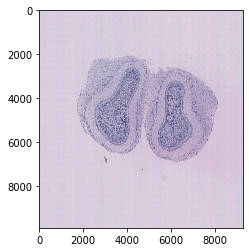

In [29]:
image = io.imread(image_file)
print(image.shape)
plt.imshow(image)
plt.show()

## Process count file

In [31]:
count = pd.read_table(count_file)
count

,Unnamed: 0,Nrf1,Zbtb5,Ccnl1,Lrrfip1,Bbs1,Lix1,Whrn,Ate1,Ubac1,...,Hist4h4,2810442I21Rik,Ctsw,A930003O13Rik,Calr3,4933433G19Rik,Ucn2,Spns3,Sftpd,Pmfbp1
0,16.92x9.015,1,1,1,2,1,2,1,1,2,...,0,0,0,0,0,0,0,0,0,0
1,16.945x11.075,0,0,3,2,2,7,0,2,3,...,0,0,0,0,0,0,0,0,0,0
2,16.97x10.118,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,16.939x12.132,1,0,1,0,4,6,1,4,3,...,0,0,0,0,0,0,0,0,0,0
4,16.949x13.055,0,0,0,3,0,2,0,2,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,23.124x24.046,0,1,2,4,2,5,0,2,7,...,0,0,0,0,0,0,0,0,0,0
258,21.01x23.944,1,0,1,0,1,1,1,2,4,...,0,0,0,0,0,0,0,0,0,0
259,22.053x23.962,2,1,0,2,1,5,2,5,5,...,0,0,0,0,0,0,0,0,0,0
260,27.018x20.088,0,1,0,0,1,0,2,1,1,...,3,1,0,0,0,0,0,0,0,0


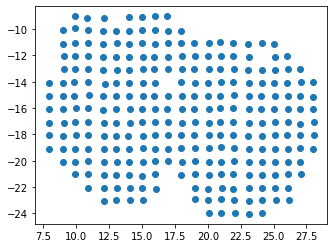

In [32]:
coords = count["Unnamed: 0"].values
coords_x = np.array([float(_.split("x")[0]) for _ in coords])
coords_y = np.array([float(_.split("x")[1]) for _ in coords])
plt.scatter(coords_x, -coords_y)
plt.gca().set_aspect('equal')
plt.show()

In [33]:
# Transformation
print(pd.read_table(transformation_file, sep=" ").columns.values)
transformation = pd.read_table(transformation_file, sep=" ").\
                 columns.values.astype(float).reshape(3, 3).T
transformation

['289.8' '0' '0.1' '0.2' '291.5' '0.3' '-289.8' '-291.5' '1']


array([[ 2.898e+02,  2.000e-01, -2.898e+02],
       [ 0.000e+00,  2.915e+02, -2.915e+02],
       [ 1.000e-01,  3.000e-01,  1.000e+00]])

[[ 2.898e+02  2.000e-01 -2.898e+02]
 [ 0.000e+00  2.915e+02 -2.915e+02]
 [ 0.000e+00  0.000e+00  1.000e+00]]


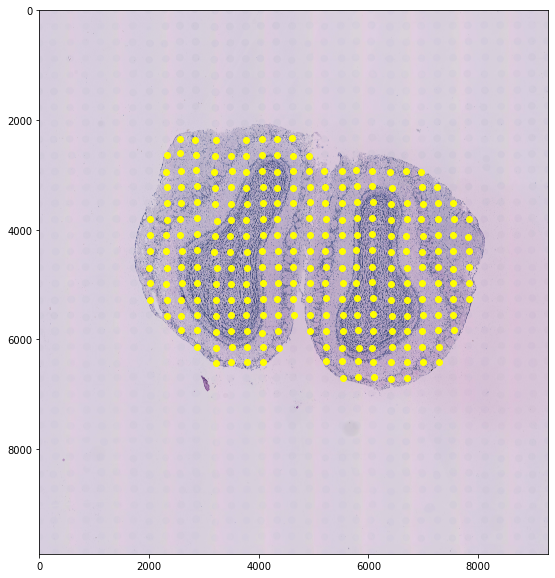

In [34]:
transformation[2, 0] = 0
transformation[2, 1] = 0
print(transformation)
tform = skimage.transform.AffineTransform(transformation)

pixels_x = []
pixels_y = []
for i in range(len(coords_x)):
    [[x, y]] = tform([coords_x[i], coords_y[i]])
    pixels_x.append(x)
    pixels_y.append(y)
    
plt.figure(figsize=(10, 10))
plt.imshow(image)
pixels_x = np.array(pixels_x)
pixels_y = np.array(pixels_y)
plt.scatter(pixels_x, pixels_y, c="yellow")
plt.gca().set_aspect('equal')
# plt.ylim((max(pixels_y), min(pixels_y)))
plt.show()

In [35]:
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

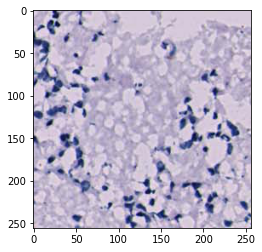

In [36]:
patch_size = 256
plt.imshow(get_image_patch(image, (pixels_x[0], pixels_y[0]), patch_size))
plt.show()

## Create data frame for genes

In [15]:
# Check count data
count_dfs = []
gene_sets = []

for count_file in count_files:
    print(count_file)
    count = pd.read_table(os.path.join(count_dir, count_file))
    print(count.shape)
    count_dfs.append(count)
    gene_sets.append(set(count.columns.values))

Rep10_MOB_count_matrix-1.tsv
(281, 16417)
Rep11_MOB_count_matrix-1.tsv
(262, 16219)
Rep12_MOB_count_matrix-1.tsv
(282, 16035)
Rep1_MOB_count_matrix-1.tsv
(267, 16574)
Rep2_MOB_count_matrix-1.tsv
(280, 15982)
Rep3_MOB_count_matrix-1.tsv
(269, 16015)
Rep4_MOB_count_matrix-1.tsv
(264, 15942)
Rep5_MOB_count_matrix-1.tsv
(267, 15291)
Rep6_MOB_count_matrix-1.tsv
(242, 16252)
Rep7_MOB_count_matrix-1.tsv
(231, 16676)
Rep8_MOB_count_matrix-1.tsv
(234, 15289)
Rep9_MOB_count_matrix-1.tsv
(237, 15285)


In [19]:
gene_set = set()
for _ in gene_sets:
    gene_set = gene_set | _
gene_set.remove("Unnamed: 0")
gene_set = list(gene_set)
gene_set.sort()
len(gene_set)

19025

0 Rep10_MOB_count_matrix-1.tsv


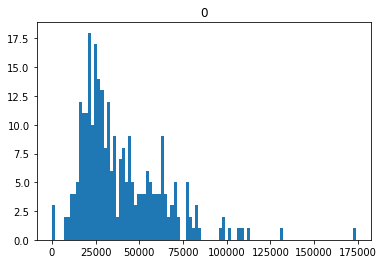

1 Rep11_MOB_count_matrix-1.tsv


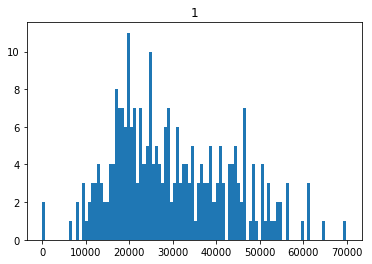

2 Rep12_MOB_count_matrix-1.tsv


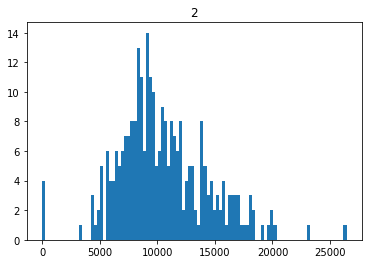

3 Rep1_MOB_count_matrix-1.tsv


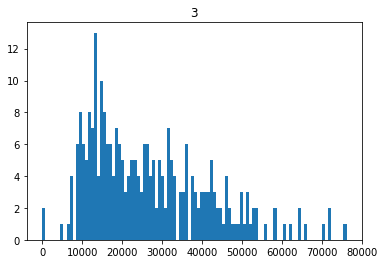

4 Rep2_MOB_count_matrix-1.tsv


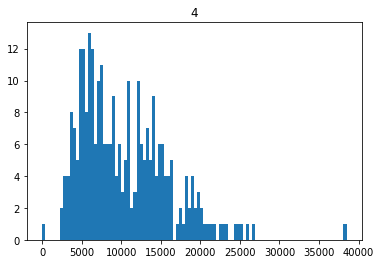

5 Rep3_MOB_count_matrix-1.tsv


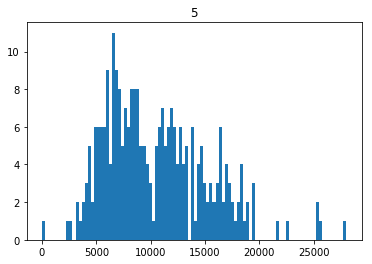

6 Rep4_MOB_count_matrix-1.tsv


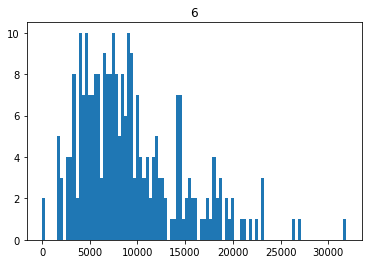

7 Rep5_MOB_count_matrix-1.tsv


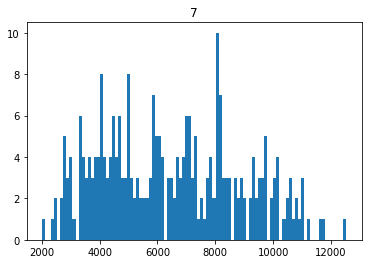

8 Rep6_MOB_count_matrix-1.tsv


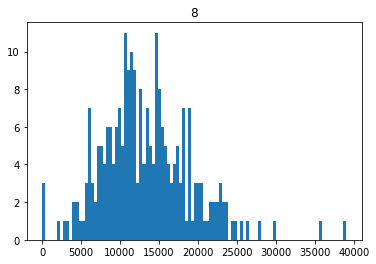

9 Rep7_MOB_count_matrix-1.tsv


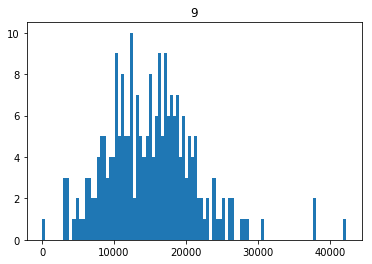

10 Rep8_MOB_count_matrix-1.tsv


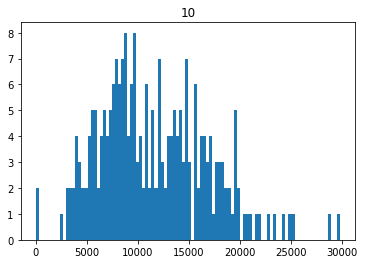

11 Rep9_MOB_count_matrix-1.tsv


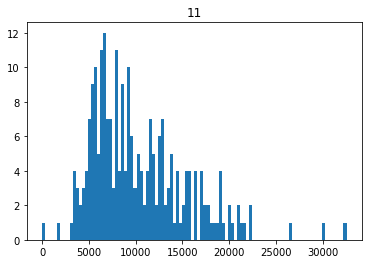

In [23]:
column_names = ['coords']
column_names.extend(gene_set)

counts_processed = dict()

for i, count_file in enumerate(count_files):
    print(i, count_file)
    count = pd.read_table(os.path.join(count_dir, count_file))
    column_names = ['coords']
    column_names.extend(gene_set)
    count_processed = pd.DataFrame(columns=column_names)
    
    count_processed['coords'] = count['Unnamed: 0']
    for gene in gene_set:
        if gene in gene_sets[i]:
            count_processed[gene] = count[gene]
        else:
            count_processed[gene] = 0
            
    # Count per million normalization
    count_sample_sum = np.sum(count_processed, 1)
    count_processed = count_processed.set_index("coords")
    for i_sample, sum_sample in enumerate(count_sample_sum):
        count_processed.iloc[i_sample, :] = count_processed.iloc[i_sample, :].values/sum_sample * 1000000
        
    plt.hist(count_sample_sum, bins=100)
    plt.title(i)
    plt.show()
    
    count_processed.to_csv("./output/Dataset_MOB/{}_count.csv".format(image_files[i].split(".")[0]))
    counts_processed[i] = count_processed

__calculate mean and variance__

In [24]:
counts_dict = dict()
for i in range(len(count_files)):
    count = counts_processed[i]
    gene_set_i = count.columns.values
    for gene in gene_set:
        if gene in gene_set_i:
            if gene in counts_dict.keys():
                counts_dict[gene].extend(list(count[gene].values))
            else:
                counts_dict[gene] = list(count[gene].values)                

In [26]:
count_stat = pd.DataFrame(columns=gene_set, index=["mean", "std", "tile_95", "non_zero_p", "max"])
for gene in gene_set:
    count_stat.loc['mean', gene] = np.average(counts_dict[gene])
    count_stat.loc['std', gene] = np.std(counts_dict[gene])
    count_stat.loc['tile_95', gene] = np.quantile(counts_dict[gene], 0.95)
    count_stat.loc['non_zero_p', gene] = np.sum(np.array(counts_dict[gene]) > 0)/len(counts_dict[gene])
    count_stat.loc['max', gene] = np.max(counts_dict[gene])

In [27]:
count_stat

,0610005C13Rik,0610007N19Rik,0610007P14Rik,0610009B14Rik,0610009B22Rik,0610009D07Rik,0610009L18Rik,0610009O20Rik,0610010B08Rik,0610010F05Rik,...,Zwint,Zxda,Zxdb,Zxdc,Zyg11b,Zyx,Zzef1,Zzz3,a,l7Rn6
mean,0.436529,21.2487,80.1625,0.139253,28.8858,95.408,12.3287,33.5157,0.0834287,41.6687,...,12.1594,24.1011,42.8964,34.1489,176.068,79.0506,67.4127,80.5465,0.542477,70.5555
std,20.5258,64.3098,98.938,4.93284,60.6244,110.651,41.4059,63.842,2.44035,74.1539,...,42.3385,61.9344,74.7977,64.3116,166.676,100.588,95.8014,106.083,7.27844,97.4977
tile_95,0,144.577,267.438,0,141.837,300.098,93.5433,154,0,189.453,...,91.5124,130.27,186.664,168.052,484.423,266.476,256.821,284.081,0,257.613
non_zero_p,0.0012837,0.177471,0.575096,0.0012837,0.293325,0.623556,0.131579,0.335045,0.0012837,0.370026,...,0.128049,0.239089,0.390565,0.330231,0.780488,0.554236,0.508665,0.560655,0.00706033,0.525032
max,1138.58,685.049,871.84,254.388,754.148,939.261,711.642,618.429,90.9835,1010.71,...,707.714,1224.99,1076.43,476.644,1239.35,1067.69,808.407,835.771,167.673,843.17


In [28]:
count_stat.to_csv("./output/Dataset_MOB/spinal_gene_set_count_stats.csv")

# Create torch dictionary for images

In [ ]:
for i, image_file in enumerate(image_files):
    image_name = image_file.split(".")[0]
    
    # Read image
    image = skimage.io.imread(os.path.join(image_dir, image_file))
    
    # Set transformation
    transformation_file = transformation_files[i]
    transformation = pd.read_table(os.path.join(transformation_dir, transformation_file), sep=" ").\
                     columns.values.astype(float).reshape(3, 3).T
    tform = skimage.transform.AffineTransform(transformation)
    transformation[2, 0] = 0
    transformation[2, 1] = 0
    print(transformation)
    
    # Get coords
    count_file = count_files[i]
    count = pd.read_table(os.path.join(count_dir, count_file))
    coords = count["Unnamed: 0"].values
    coords_x = np.array([float(_.split("x")[0]) for _ in coords])
    coords_y = np.array([float(_.split("x")[1]) for _ in coords])
    
    # Get pixel coords
    pixels_x = []
    pixels_y = []
    for i in range(len(coords_x)):
        [[x, y]] = tform([coords_x[i], coords_y[i]])
        pixels_x.append(x)
        pixels_y.append(y)
    
    patch_size = 256
    image_dict = dict()
    for i in range(len(coords_x)):
        image_dict['{}x{}'.format(coords_x[i], coords_y[i])] = get_image_patch(image, (pixels_x[i], pixels_y[i]), patch_size)
        
    torch.save(image_dict, "./output/Dataset_MOB/image_{}_dict.pt".format(image_name))